# Машинное обучение, DS-поток
## Задание ML.11

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.

**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash; 60 баллов;
* Задача 2 &mdash; 70 баллов;
* Задача 3 &mdash; 50 баллов;
* Задача 4 &mdash; 70 баллов.


In [ ]:
# Bot check

# HW_ID: ds_ml11
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

In [36]:
import os, time, random, math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from typing import Any, Tuple, List, Optional, Union, Callable
from typing import Callable
from torch.optim import Optimizer

from sklearn.cluster import KMeans
from matplotlib.patches import Rectangle
from torchmetrics.detection import MeanAveragePrecision
from tqdm.notebook import tqdm

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| Device:", device)

BATCH_SIZE = 8

Torch: 2.8.0+cu128 | Device: cuda


#### Предисловие
Линейка моделей **YOLO (You Only Look Once)** — одна из самых успешных и активно развивающихся серий методов для детекции объектов в реальном времени. На момент своего выхода **YOLOv3 (2018)** считалась **state-of-the-art** среди моделей реального времени, предлагая выдающийся баланс между скоростью и точностью и став де-факто стандартом для практических приложений. Спустя несколько лет эволюции, **YOLOv8 (2023)** вновь закрепила лидерство серии, став одной из **SOTA-моделей** своего времени: она отказалась от анкоров (anchor-free), получила новую модульную архитектуру и поддержку множества задач — от детекции и сегментации до классификации и оценки поз. На занятии вы уже подробно реализовали **YOLOv3** с нуля, разобрав её архитектуру и принципы работы, а теперь вам предстоит **итерационно обновить YOLOv3, приближаясь к версии YOLOv8**, шаг за шагом реализуя эволюционные изменения и улучшения, чтобы на практике проследить развитие и совершенствование этой легендарной линейки.

### Задача 1

В этой задаче мы закрепим материал, пройденный на последнем занятии, где вы уже ознакомились с реализацией архитектуры **YOLOv3**, и теперь вам предстоит применить эти знания на практике. Работать вы будете с набором данных **Blood Cell Detection Dataset**, на котором пройдёте весь путь от обучения модели и подбора её параметров до оценки качества и визуализации результатов.

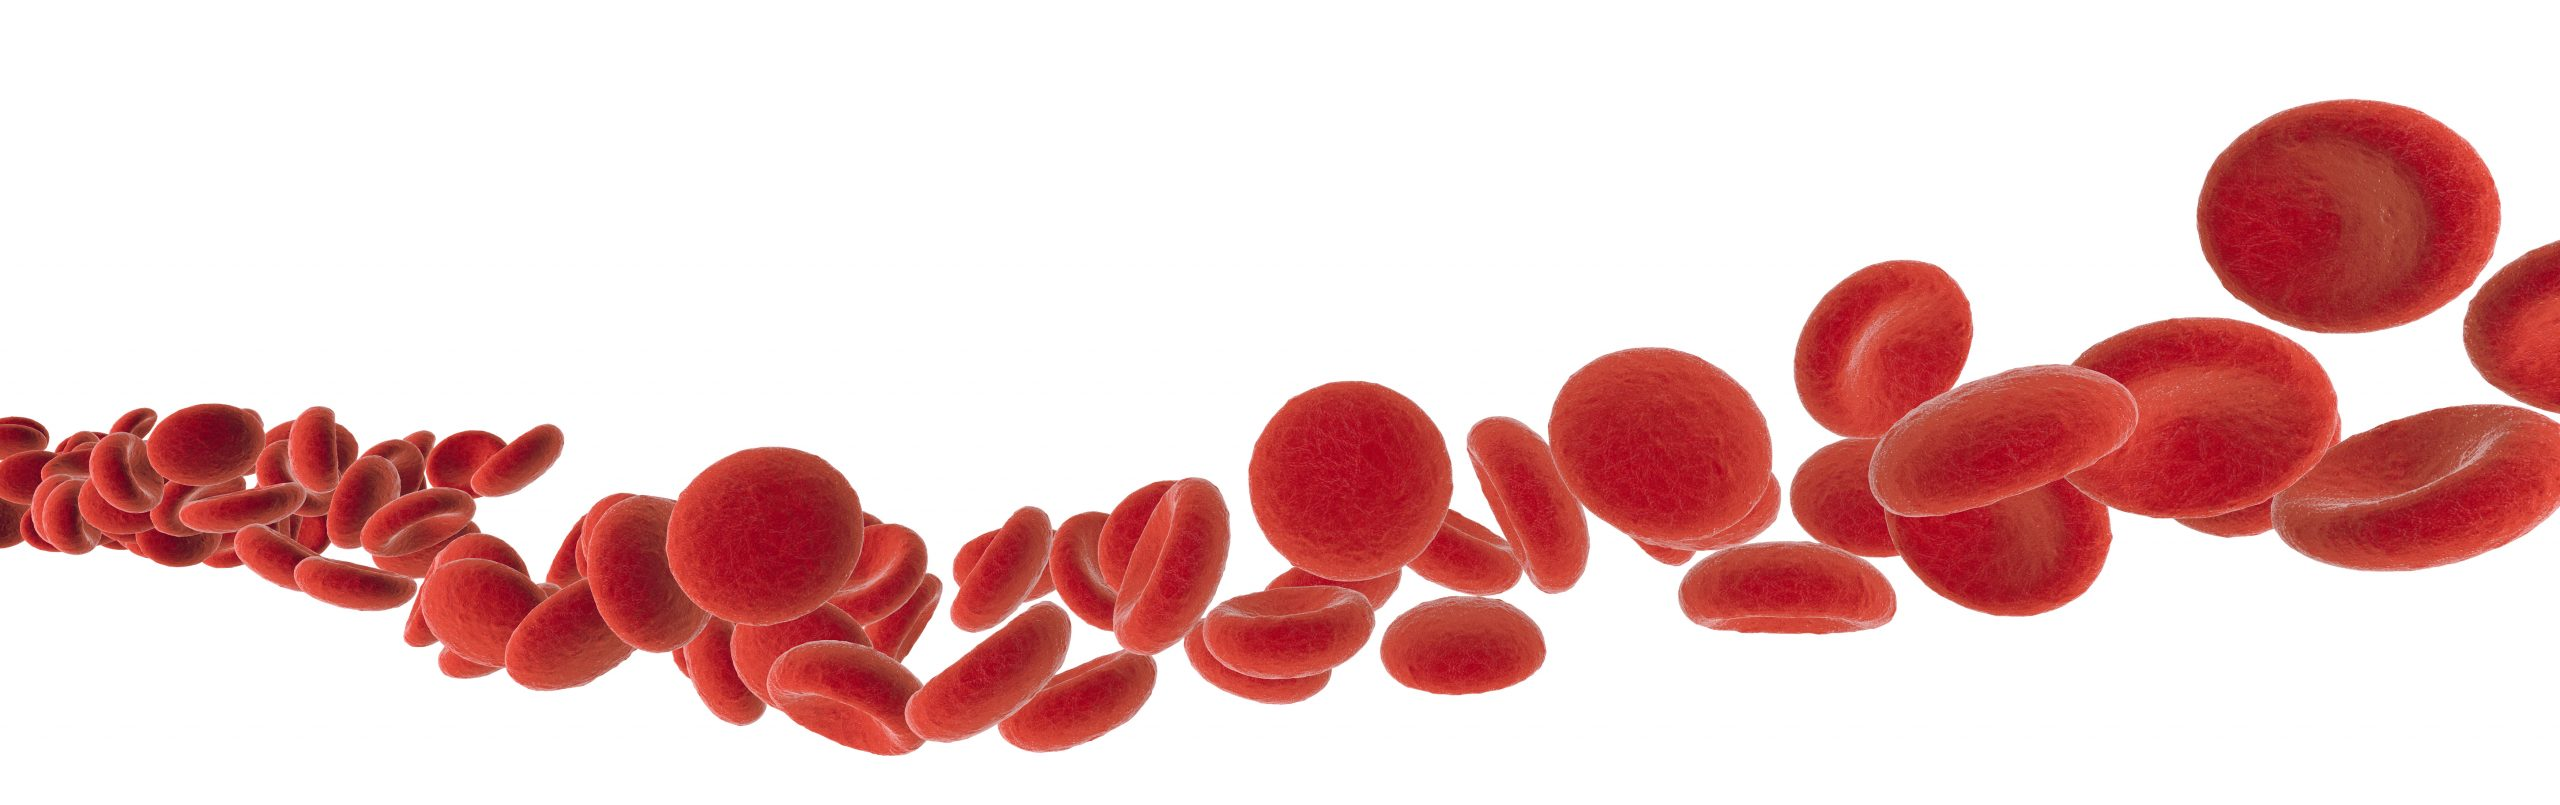

[Blood Cell Detection Dataset](https://www.kaggle.com/datasets/adhoppin/blood-cell-detection-datatset/data) — набор изображений мазков крови, предназначенный для обучения моделей детекции. Датасет содержит фотографии клеток крови с разметкой трёх классов: **эритроцитов (RBC)**, **лейкоцитов (WBC)** и **тромбоцитов (Platelets)**. Детекция клеток крови имеет важное практическое значение: она помогает автоматизировать анализ крови и выявлять патологии.

Для удобства работы с данными для вас реализован класс датасета.

In [2]:
class BloodCellDataset(Dataset):
    """
    PyTorch-датасет для BloodCell Detection Dataset в cx-cy-w-h формате.

    Ожидаемая структура:
        root_dir/
          train|valid|test/
            images/*.jpg
            labels/*.txt  (label cx cy w h, координаты нормализованы [0,1])

    Предполагается, что все изображения уже приведены к одному размеру (416×416).

    На выходе:
        image : Tensor (3, H, W)
        target: dict с полями
            "boxes"  — Tensor (N,4) в cxcxwh-формате,
            "labels" — Tensor (N,) с индексами классов,
            "path"   — путь до исходного файла.
    """

    def __init__(self, root_dir: str | Path, split: str = "train"):
        """Инициализирует датасет, находя пути ко всем изображениям.

        Args:
            root_dir (str | Path): Путь к корневой директории датасета.
            split (str, optional): Сплит данных ("train", "valid", "test").
                По умолчанию "train".
        """
        assert split in ["train", "valid", "test"]
        split_dir = Path(root_dir) / split
        self.img_dir = split_dir / "images"
        self.label_dir = split_dir / "labels"

        exts = {".jpg", ".jpeg", ".png"}
        self.img_paths = sorted([p for p in self.img_dir.rglob("*") 
                                 if p.suffix.lower() in exts and ".ipynb_checkpoints" not in p.as_posix()])

    def __len__(self) -> int:
        """Возвращает общее количество изображений в датасете."""
        return len(self.img_paths)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, dict]:
        """Загружает и возвращает один элемент датасета по индексу.

        Args:
            idx (int): Индекс запрашиваемого элемента.

        Returns:
            tuple[torch.Tensor, dict]: Кортеж (image, target), где:
                - image: тензор изображения (C, H, W).
                - target: словарь с аннотациями {"boxes", "labels", "path"}.
        """
        ip = self.img_paths[idx]
        lbl = self.label_dir / (ip.stem + ".txt")

        # Считываем изображение
        img = Image.open(ip).convert("RGB")

        # Считываем координаты боксов и классы
        boxes = []
        labels = []
        if lbl.exists():
            with open(lbl, "r") as f:
                for line in f.read().strip().splitlines():
                    vals = line.strip().split()
                    if len(vals) >= 5:
                        labels.append(int(float(vals[0])))
                        cx, cy, w, h = map(float, vals[1:5])
                        boxes.append([cx, cy, w, h])

        img_t = transforms.ToTensor()(img)
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels, "path": str(ip)}
        return img_t, target

Для формирования бачта в `DataLoader` понадобится функция `collate_fn`.

In [3]:
def collate_fn(batch):
    """
    Эта функция поясняет DataLoader как комбинировать данные в батч.
    Для этого мы будем использовать списки.
    Аргумент:
      batch: итерируемый объект из __getitem__()
    Возвращает:
      тензор картинок, список тензоров боксов, список тензоров лейблов
    """
    images = []
    boxes = []
    labels = []

    for b in batch:
        images.append(b[0])
        boxes.append(b[1]["boxes"])
        labels.append(b[1]["labels"])

    images = torch.stack(images)

    return images, boxes, labels

Набор данных уже разбит на train, val и test. Подготовьте соответствующие датасеты и даталоадеры.

In [4]:
train_dataset = BloodCellDataset('./', 'train')
val_dataset = BloodCellDataset('./', 'valid')
test_dataset = BloodCellDataset('./', 'test')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=False)

Определим параметры датасета.

In [5]:
IMG_SIZE = 416  # Размер квадратного изображения
NUM_CLASSES = 3  # Кол-во классов
CLASS_NAMES: list[str] = [
    "WBC",  # class 0 лейкоциты
    "RBC",  # class 1 эритроциты
    "Platelets",  # class 2 тромбоциты
]

Датасет оперирует координатами бокса, где каждый бокс определяется нормализованными координатами центра и нормализованными размерами. Однако для визуализации боксов необходимы абсолютные пиксельные координаты левого верхнего угла и нижнего правого. Для этого предназначена следующая функция.

In [38]:
def cxcywh_to_x1y1x2y2(cx, cy, w, h):
def cxcywh_to_x1y1x2y2(cx, cy, w, h):
    """Конвертирует координаты прямоугольника из формата (центр, размеры) в (углы).

    Args:
        cx (float): Нормализованная координата X центра прямоугольника.
        cy (float): Нормализованная координата Y центра прямоугольника.
        w (float): Нормализованная ширина прямоугольника.
        h (float): Нормализованная высота прямоугольника.

    Returns:
        tuple[float, float, float, float]: Кортеж с абсолютными пиксельными
            координатами (xmin, ymin, xmax, ymax), где (xmin, ymin) — это
            верхний левый угол, а (xmax, ymax) — нижний правый.
    """
    xmin, xmax = (cx - w / 2) * IMG_SIZE, (cx + w / 2) * IMG_SIZE
    ymin, ymax = (cy - h / 2) * IMG_SIZE, (cy + h / 2) * IMG_SIZE
    return xmin, ymin, xmax, ymax

Функция для отображения боксов на изображении.

In [7]:
CLASS_COLORS: list[str] = [
    "white",  # class 0
    "red",  # class 1
    "cyan",  # class 2
]


def draw_img_boxes(
    img_t: torch.Tensor,
    boxes: Union["np.ndarray", torch.Tensor],
    labels: Optional[Union["np.ndarray", torch.Tensor]] = None,
    scores: Optional[Union["np.ndarray", torch.Tensor]] = None,
) -> "Image.Image":
    """
    Рисует прямоугольники (bounding boxes) цветом в зависимости от класса.

    Args:
        img_t: Изображение в формате тензора формы (C, H, W).
        boxes: Массив или тензор боксов формы (N, 4) в формате xyxy.
        labels: Необязательный массив или тензор меток классов формы (N,).
            Если не указан, используется цвет по умолчанию.
        scores: Необязательный массив или тензор confidence-оценок формы (N,).
            Если указан, значение выводится рядом с меткой класса.

    Returns:
        PIL-изображение с нарисованными bounding boxes.
    """
    # Преобразуем тензор в PIL изображение
    img = transforms.ToPILImage()(img_t.cpu()).convert("RGB")

    # Создаем контекст для рисования на изображении
    draw = ImageDraw.Draw(img)

    # Преобразуем таргет в numpy формат
    if isinstance(boxes, torch.Tensor):
        boxes = boxes.cpu().numpy()
    if labels is not None and isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    if scores is not None and isinstance(scores, torch.Tensor):
        scores = scores.cpu().numpy()

    # Рисуем боксы с подписями
    n = len(boxes)
    for i in range(n):
        cx, cy, w, h = [float(x) for x in boxes[i]]
        x1, y1, x2, y2 = cxcywh_to_x1y1x2y2(cx, cy, w, h)
        c_id = int(labels[i]) if labels is not None and i < len(labels) else 0
        c_name = CLASS_NAMES[c_id]
        color = CLASS_COLORS[c_id % len(CLASS_COLORS)]
        # Рисуем боксы
        draw.rectangle([x1, y1, x2, y2], outline=color, width=2)
        if labels is not None:
            txt = str(c_name)
            # Также можно показать уверенность предсказания
            if scores is not None and i < len(scores):
                txt += f" p={scores[i]:.2f}"
            # К боксам добавляем текст
            draw.text((x1 + 2, y1 + 2), txt, fill=color)
    return img

Отобразите несколько примеров из датасета.

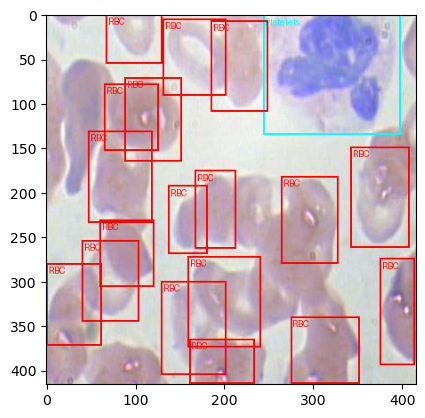

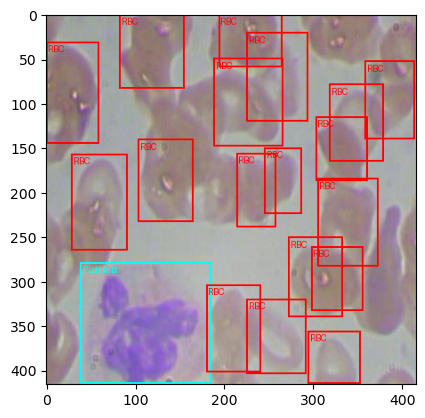

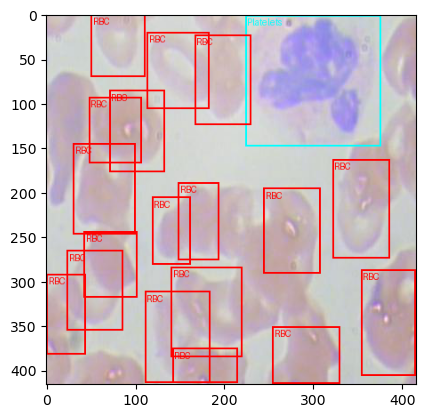

In [8]:
for i in range(3):
    ex = train_dataset[i]
    plt.imshow(draw_img_boxes(ex[0], ex[1]['boxes'], ex[1]['labels']))
    plt.show()

Выполните следующий **алгоритм действий для обучения и тестирования** модели **YOLOv3**, реализованную на занятии.
1. Подберите оптимальные размеры анкеров.
2. Обучите модель YOLOv3 на обучающем наборе данных.
3. Оцените среднее время работы модели при обучении.
4. Подберите оптимальные пороги по confidence и IoU для NMS на валидационной части данных по метрике mAP@.50:.95.
5. Оцените качество модели на тестовых данных по метрикам mAP@.50:.95, mAP@.50, mAP@.75.
6. Оцените время работы модели при тестировании.
7. Визуализируйте результаты детекции на нескольких примерах из тестовой части данных.

Постарайтесь сделать код обучения и тестирования достаточно универсальным, чтобы его можно было использовать и для следующих задач в этом задании.

In [9]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding=None):
        super(CNNBlock, self).__init__()

        if padding is None:
            padding = kernel_size // 2

        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride,
                              padding, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, x):
        return self.activation(self.bn(self.conv(x)))


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            CNNBlock(channels, channels // 2, kernel_size=1, stride=1),
            CNNBlock(channels // 2, channels, kernel_size=3, stride=1)
        )

    def forward(self, x):
        return x + self.block(x)

In [10]:
class Darknet53(nn.Module):
    def __init__(self):
        super().__init__()

        self._make_residual_layer = lambda c, n: nn.Sequential(*[ResidualBlock(c) for _ in range(n)])

        self.conv_in = CNNBlock(3, 32, kernel_size=3, stride=1)

        self.stage1 = nn.Sequential(CNNBlock(32, 64, 3, 2), self._make_residual_layer(64, 1))
        self.stage2 = nn.Sequential(CNNBlock(64, 128, 3, 2), self._make_residual_layer(128, 2))
        self.stage3 = nn.Sequential(CNNBlock(128, 256, 3, 2), self._make_residual_layer(256, 8))
        self.stage4 = nn.Sequential(CNNBlock(256, 512, 3, 2), self._make_residual_layer(512, 8))
        self.stage5 = nn.Sequential(CNNBlock(512, 1024, 3, 2), self._make_residual_layer(1024, 4))

    def forward(self, x):
        x = self.conv_in(x)
        x = self.stage1(x)
        x = self.stage2(x)
        p3 = self.stage3(x)
        p4 = self.stage4(p3)
        p5 = self.stage5(p4)

        return p3, p4, p5

In [11]:
class YOLONeck_FPN(nn.Module):
    def __init__(self):
        super().__init__()

        self._make_neck = lambda in_c, out_c: nn.Sequential(
            CNNBlock(in_c, out_c, 1, 1),
            CNNBlock(out_c, out_c * 2, 3, 1),
            CNNBlock(out_c * 2, out_c, 1, 1),
            CNNBlock(out_c, out_c * 2, 3, 1),
            CNNBlock(out_c * 2, out_c, 1, 1)
        )

        self._upsample = lambda in_c, out_c: nn.Sequential(
            CNNBlock(in_c, out_c, 1, 1),
            nn.Upsample(scale_factor=2, mode='nearest')
        )

        self.neck_p5 = self._make_neck(1024, 512)
        self.upsample_p5_to_p4 = self._upsample(512, 256)
        self.neck_p4 = self._make_neck(768, 256)
        self.upsample_p4_to_p3 = self._upsample(256, 128)
        self.neck_p3 = self._make_neck(384, 128)

    def forward(self, p3_in, p4_in, p5_in):
        features_p5 = self.neck_p5(p5_in)
        upsampled_p5 = self.upsample_p5_to_p4(features_p5)
        combined_p4 = torch.cat([upsampled_p5, p4_in], dim=1)
        features_p4 = self.neck_p4(combined_p4)
        upsampled_p4 = self.upsample_p4_to_p3(features_p4)
        combined_p3 = torch.cat([upsampled_p4, p3_in], dim=1)
        features_p3 = self.neck_p3(combined_p3)

        return features_p3, features_p4, features_p5

In [12]:
class PredictionHead(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.head = nn.Sequential(
            CNNBlock(in_channels, in_channels * 2, kernel_size=3, stride=1),
            nn.Conv2d(in_channels * 2, out_channels, kernel_size=1, stride=1, padding=0, bias=True)
        )
    def forward(self, x):
        return self.head(x)


class YOLOHeads(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        out_ch = 3 * (5 + num_classes)
        self.head_p3 = PredictionHead(in_channels=128, out_channels=out_ch)
        self.head_p4 = PredictionHead(in_channels=256, out_channels=out_ch)
        self.head_p5 = PredictionHead(in_channels=512, out_channels=out_ch)

    def forward(self, n3, n4, n5):
        out_p3 = self.head_p3(n3)
        out_p4 = self.head_p4(n4)
        out_p5 = self.head_p5(n5)
        return out_p3, out_p4, out_p5

In [13]:
class YOLOv3(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = Darknet53()
        self.neck = YOLONeck_FPN()
        self.head = YOLOHeads(num_classes=num_classes)
        self.num_classes = num_classes
        self.num_anchors = 3

    def _format_output(self, tensor):
        B, C, H, W = tensor.shape
        tensor = tensor.view(B, self.num_anchors, -1, H, W)
        tensor = tensor.permute(0, 3, 4, 1, 2).contiguous()
        return tensor

    def forward(self, x):
        p3, p4, p5 = self.backbone(x)
        n3, n4, n5 = self.neck(p3, p4, p5)
        raw_out_p3, raw_out_p4, raw_out_p5 = self.head(n3, n4, n5)
        out_p3 = self._format_output(raw_out_p3)
        out_p4 = self._format_output(raw_out_p4)
        out_p5 = self._format_output(raw_out_p5)
        return [out_p5, out_p4, out_p3]

In [14]:
class BoxLoss(nn.Module):
    """Штрафует за ошибки в предсказании координат бокса"""
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()

    def forward(self, pred_box, target_box, obj_mask):
        if not obj_mask.any():
            return 0.0

        # Loss для координат центра бокса
        loss_box_xy = self.mse(pred_box[..., 0:2][obj_mask], target_box[..., 0:2][obj_mask])

        # Loss для ширины и высоты бокса
        loss_box_wh = self.mse(pred_box[..., 2:4][obj_mask], target_box[..., 2:4][obj_mask])

        return loss_box_xy + loss_box_wh

class ObjectnessLoss(nn.Module):
    """Штрафует за ошибки в предсказании наличия/отсутствия объекта"""
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred_obj, target_obj, obj_mask, noobj_mask):
        loss_obj = self.bce(pred_obj[obj_mask], target_obj[obj_mask]) if obj_mask.any() else 0.0
        loss_noobj = self.bce(pred_obj[noobj_mask], target_obj[noobj_mask]) if noobj_mask.any() else 0.0
        return loss_obj, loss_noobj

class ClassLoss(nn.Module):
    """Штрафует за ошибки в предсказании класса объекта"""
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred_class, target_class, obj_mask):
        if not obj_mask.any():
            return 0.0
        loss_class = self.bce(pred_class[obj_mask], target_class[obj_mask])
        return loss_class

In [15]:
def bbox_iou(box1, box2, x1y1x2y2=True):
    """
    Вычисляет IOU для 2х боксов
    """
    if not x1y1x2y2:
        # Переводим из координат центра и ширины в формат x1y1x2y2
        b1_x1, b1_x2 = box1[:, 0] - box1[:, 2] / 2, box1[:, 0] + box1[:, 2] / 2
        b1_y1, b1_y2 = box1[:, 1] - box1[:, 3] / 2, box1[:, 1] + box1[:, 3] / 2
        b2_x1, b2_x2 = box2[:, 0] - box2[:, 2] / 2, box2[:, 0] + box2[:, 2] / 2
        b2_y1, b2_y2 = box2[:, 1] - box2[:, 3] / 2, box2[:, 1] + box2[:, 3] / 2
    else:
        # Получаем координаты боксов
        b1_x1, b1_y1, b1_x2, b1_y2 = box1[:, 0], box1[:, 1], box1[:, 2], box1[:, 3]
        b2_x1, b2_y1, b2_x2, b2_y2 = box2[:, 0], box2[:, 1], box2[:, 2], box2[:, 3]

    # Считаем координаты квадрата пересечения
    inter_rect_x1 = torch.max(b1_x1, b2_x1)
    inter_rect_y1 = torch.max(b1_y1, b2_y1)
    inter_rect_x2 = torch.min(b1_x2, b2_x2)
    inter_rect_y2 = torch.min(b1_y2, b2_y2)

    # Площадь пересечения
    inter_area = torch.clamp(inter_rect_x2 - inter_rect_x1 + 1, min=0) * torch.clamp(
        inter_rect_y2 - inter_rect_y1 + 1, min=0
    )

    # Площади первого и второго боксов
    b1_area = (b1_x2 - b1_x1 + 1) * (b1_y2 - b1_y1 + 1)
    b2_area = (b2_x2 - b2_x1 + 1) * (b2_y2 - b2_y1 + 1)

    # IoU
    iou = inter_area / (b1_area + b2_area - inter_area + 1e-16)

    return iou

In [16]:
class TargetBuilder(nn.Module):
    def __init__(self, anchors_by_scale, num_classes=7, ignore_thresh=0.5):
        """
        Инициализирует TargetBuilder для создания целевых меток YOLO.

        Args:
            anchors_by_scale (list of torch.Tensor): Список тензоров, где каждый тензор содержит якоря [width, height]
                                                   для соответствующего масштаба (P5, P4, P3).
            num_classes (int, optional): Количество классов для обнаружения. По умолчанию 7.
            ignore_thresh (float, optional): IoU-порог, выше которого предсказания считаются 'игнорируемыми'
                                           для расчета objectness loss. По умолчанию 0.5.
        """
        super().__init__()
        self.num_classes = num_classes
        self.ignore_thresh = ignore_thresh

        # self.anchors - это анкеры в ПИКСЕЛЯХ (e.g., [116, 90])
        self.anchors = anchors_by_scale
        self.num_anchors = 3

        # Размеры сеток
        self.grid_sizes = [13, 26, 52]
        # Страйды для 416x416.
        # (416/13=32, 416/26=16, 416/52=8)
        self.strides = [32, 16, 8]
        # Масштабированные анкеры.
        # Мы делим пиксельные анкеры на страйд, чтобы получить
        # анкеры в "сеточных" единицах (grid units)
        self.anchors_grid_units = [
            anchors.float() / stride
            for anchors, stride in zip(self.anchors, self.strides)
        ]


    def forward(self, predictions, targets):
        """
        Создает целевые тензоры для YOLO-Loss.

        Args:
            predictions (list of torch.Tensor): Список предсказаний модели для каждого масштаба (P5, P4, P3).
                                              Каждый тензор имеет форму (B, S, S, num_anchors, 5 + num_classes).
            targets (torch.Tensor): Тензор истинных меток (Ground Truth) объектов в батче.
                                    Формат: (N, 6), где N - общее количество объектов в батче,
                                    а 6 включает [batch_idx, class_id, cx, cy, w, h] (нормализованные).

        Returns:
            tuple: Кортеж из трех списков:
                - all_obj_masks (list of torch.Tensor): Маски, указывающие, какие якоря соответствуют объектам.
                - all_noobj_masks (list of torch.Tensor): Маски, указывающие, какие якоря не соответствуют объектам
                                                        и не игнорируются.
                - all_target_tensors (list of torch.Tensor): Целевые тензоры для каждой головы YOLO.
                                                           Формат: (B, S, S, num_anchors, 5 + num_classes).
        """
        all_obj_masks = []
        all_noobj_masks = []
        all_target_tensors = []

        # (predictions идет в порядке P5, P4, P3,
        # поэтому grid_sizes и anchors должны быть в том же порядке)
        for scale_idx, p in enumerate(predictions):
            B, S, _, A, _ = p.shape # S = 13, 26, или 52 (grid_size)

            obj_mask = torch.zeros((B, S, S, A), dtype=torch.bool, device=p.device)
            noobj_mask = torch.ones((B, S, S, A), dtype=torch.bool, device=p.device)
            target_box_coords = torch.zeros((B, S, S, A, 4), device=p.device)
            target_obj_conf = torch.zeros((B, S, S, A, 1), device=p.device)
            target_class_probs = torch.zeros((B, S, S, A, self.num_classes), device=p.device)

            # Берем анкеры, УЖЕ сконвертированные в "сеточные" единицы
            current_anchors_grid = self.anchors_grid_units[scale_idx].to(p.device)

            for t in targets:
                batch_idx, t_class, t_x, t_y, t_w, t_h = t
                batch_idx = int(batch_idx)

                # --- Приводим GT к "сеточным" единицам ---
                # (t_x, t_y, t_w, t_h) - нормализованные (0-1)

                # Координаты центра в "сеточных" единицах
                t_x_grid = t_x * S
                t_y_grid = t_y * S
                # Ширина и высота в "сеточных" единицах
                t_w_grid = t_w * S
                t_h_grid = t_h * S

                # Индексы ячейки (i, j)
                j, i = int(t_x_grid), int(t_y_grid)
                if i >= S or j >= S:
                    continue # пропустить, если бокс за пределами сетки

                # 1. GT бокс (в "сеточных" единицах)
                gt_box_grid = torch.tensor([0, 0, t_w_grid, t_h_grid], device=p.device).unsqueeze(0)

                # 2. Анкеры (в "сеточных" единицах)
                anchor_shapes_grid = torch.cat([
                    torch.zeros_like(current_anchors_grid),
                    current_anchors_grid
                ], dim=1)

                # 3. Считаем IoU
                ious = bbox_iou(gt_box_grid, anchor_shapes_grid, x1y1x2y2=False)

                # 4. Находим походящий анкер
                best_a = ious.argmax()

                # 5. Обновляем маски, указывающие, какие якоря соответствуют объектам,
                # и маски, указывающие, какие якоря не соответствуют объектам и не игнорируются.
                obj_mask[batch_idx, i, j, best_a] = 1
                noobj_mask[batch_idx, i, j, best_a] = 0
                noobj_mask[batch_idx, i, j, ious > self.ignore_thresh] = 0

                # 6. Считаем смещение центра таргета от центра ячейки
                target_box_coords[batch_idx, i, j, best_a, 0] = t_x_grid - j
                target_box_coords[batch_idx, i, j, best_a, 1] = t_y_grid - i

                # 7. Считаем отличия в масштабе размеров таргета от размеров анкера
                target_box_coords[batch_idx, i, j, best_a, 2] = torch.log(
                    t_w_grid / current_anchors_grid[best_a, 0] + 1e-16
                )
                target_box_coords[batch_idx, i, j, best_a, 3] = torch.log(
                    t_h_grid / current_anchors_grid[best_a, 1] + 1e-16
                )

                # 8. Также записываем конфиденс и вероятность для нужного анкера для нужного класса
                target_obj_conf[batch_idx, i, j, best_a] = 1.0
                target_class_probs[batch_idx, i, j, best_a, int(t_class)] = 1.0

            all_obj_masks.append(obj_mask)
            all_noobj_masks.append(noobj_mask)
            all_target_tensors.append(
                torch.cat([target_box_coords, target_obj_conf, target_class_probs], dim=-1)
            )

        return all_obj_masks, all_noobj_masks, all_target_tensors

In [17]:
class YoloLoss(nn.Module):
    def __init__(self, anchors_by_scale, num_classes=3, ignore_thresh=0.5):
        """
        Инициализирует функцию потерь YOLO (YoloLoss).

        Args:
            anchors_by_scale (list of torch.Tensor): Список тензоров, где каждый тензор содержит якоря [width, height]
                                                   для соответствующего масштаба (P5, P4, P3).
            num_classes (int, optional): Количество классов для обнаружения. По умолчанию 3.
            ignore_thresh (float, optional): IoU-порог для игнорирования предсказаний без объектов.
                                           По умолчанию 0.5.
        """
        super().__init__()
        self.target_builder = TargetBuilder(anchors_by_scale, num_classes, ignore_thresh)
        self.box_loss_fn = BoxLoss()
        self.obj_loss_fn = ObjectnessLoss()
        self.cls_loss_fn = ClassLoss()
        self.lambda_class = 1.0
        self.lambda_obj = 1.0
        self.lambda_noobj = 10.0
        self.lambda_box = 10.0

    def forward(self, predictions, targets):
        """
        Вычисляет общую функцию потерь YOLO для данного батча.

        Args:
            predictions (list of torch.Tensor): Список предсказаний модели для каждого масштаба (P5, P4, P3).
                                              Каждый тензор имеет форму (B, S, S, num_anchors, 5 + num_classes).
            targets (torch.Tensor): Тензор истинных меток (Ground Truth) объектов в батче.
                                    Формат: (N, 6), где N - общее количество объектов в батче,
                                    а 6 включает [batch_idx, class_id, cx, cy, w, h] (нормализованные).

        Returns:
            torch.Tensor: Общая функция потерь для батча.
        """
        # 1. Построение целевых тензоров (ground truth) для каждого масштаба
        # Это включает маски для объектов, отсутствия объектов и форматированные целевые данные
        obj_masks, noobj_masks, target_tensors = self.target_builder(predictions, targets)

        total_loss = 0
        # Получаем размер батча из первого предсказания
        B = predictions[0].shape[0]

        # 2. Итерация по каждому масштабу предсказаний (P5, P4, P3)
        for i, p in enumerate(predictions):
            # Разделение предсказаний на компоненты: координаты бокса, уверенность в объекте, вероятности классов
            pred_box = p[..., 0:4]      # (tx, ty, tw, th)
            pred_obj = p[..., 4:5]      # (to) objectness score
            pred_class = p[..., 5:]     # (c1, c2, ..., cn) class probabilities

            # Извлечение соответствующих целевых данных для текущего масштаба
            target_box = target_tensors[i][..., 0:4]
            target_obj = target_tensors[i][..., 4:5]
            target_class = target_tensors[i][..., 5:]

            # Извлечение масок для объектов и отсутствия объектов
            obj_mask = obj_masks[i]
            noobj_mask = noobj_masks[i]

            # 3. Вычисление отдельных компонентов лосс
            loss_box = self.box_loss_fn(pred_box, target_box, obj_mask)
            loss_obj, loss_noobj = self.obj_loss_fn(pred_obj, target_obj, obj_mask, noobj_mask)
            loss_class = self.cls_loss_fn(pred_class, target_class, obj_mask)

            # 4. Комбинирование компонентов лосса с весами
            # Эти веса (лямбды) позволяют настроить важность каждого типа ошибки
            scale_loss = (
                self.lambda_box * loss_box +
                self.lambda_obj * loss_obj +
                self.lambda_noobj * loss_noobj +
                self.lambda_class * loss_class
            )
            # Добавление лосса текущего масштаба к общему лоссу
            total_loss += scale_loss

        # 5. Нормализация общего лосса по размеру батча
        return total_loss / B

In [18]:
def calculate_anchors(
    all_scaled_boxes_wh,
    num_anchors=9,
):
    """
    Вычисляет оптимальные якоря для YOLOv3, используя k-means
    исключительно на данных из тренировочной выборки (train_files).

    Боксы нормализуются по оригинальному размеру, а затем масштабируются
    к input_size (416x416), т.к. k-means нужно проводить
    в пространстве, к которому будут привязаны предсказания.
    """

    if not all_scaled_boxes_wh:
        print("Не найдено ни одного бокса. Невозможно рассчитать анкеры.")
        return None

    # --- K-Means ---
    all_scaled_boxes_wh = np.array(all_scaled_boxes_wh)
    print(f"Собрано {len(all_scaled_boxes_wh)} боксов для k-means кластеризации.")

    kmeans = KMeans(n_clusters=num_anchors, random_state=42, n_init=10)
    anchors_lables = kmeans.fit_predict(all_scaled_boxes_wh)

    # Центроиды - это и есть наши анкеры [w, h] в пикселях (масштаб 416)
    anchors_pixels = kmeans.cluster_centers_

    # Визуализация кластеров
    plt.figure(figsize=(7, 7))
    plt.scatter(all_scaled_boxes_wh[:, 0], all_scaled_boxes_wh[:, 1], c=anchors_lables, alpha=0.3, label='целевые боксы')
    plt.scatter(anchors_pixels[:, 0], anchors_pixels[:, 1], c="black", marker='*', label='анкеры', s=50)
    plt.xlabel('Ширина бокса')
    plt.ylabel('Высота бокса')
    plt.legend()
    plt.gca().set_aspect(1.)

    # 1. Сортируем по площади (от меньшего к большему)
    areas = anchors_pixels[:, 0] * anchors_pixels[:, 1]
    sorted_indices = np.argsort(areas)
    anchors_sorted = anchors_pixels[sorted_indices]

    # 2. Округляем и разбиваем на 3 группы (P3, P4, P5)
    anchors_pixels_rounded = np.round(anchors_sorted).tolist()

    anchors_p3 = torch.tensor(anchors_pixels_rounded[0:3]) # мелкие
    anchors_p4 = torch.tensor(anchors_pixels_rounded[3:6]) # средние
    anchors_p5 = torch.tensor(anchors_pixels_rounded[6:9]) # крупные

    print("\nРассчитанные анкеры (пиксели, масштаб 416x416):")
    print(f"P3 (мелкие): {anchors_p3.tolist()}")
    print(f"P4 (средние): {anchors_p4.tolist()}")
    print(f"P5 (крупные): {anchors_p5.tolist()}")

    # Возвращаем в том порядке, который ожидает YoloLoss (P5, P4, P3)
    return [anchors_p5, anchors_p4, anchors_p3]

In [19]:
all_scaled_boxes_wh = []
for ex in train_dataset:
    for box in ex[1]['boxes']:
        norm_w, norm_h = box[-2:]
        scaled_w = norm_w * IMG_SIZE
        scaled_h = norm_h * IMG_SIZE
        all_scaled_boxes_wh.append([scaled_w, scaled_h])
np.save('all_scaled_boxes_wh.npy', all_scaled_boxes_wh)

Собрано 10342 боксов для k-means кластеризации.

Рассчитанные анкеры (пиксели, масштаб 416x416):
P3 (мелкие): [[31.0, 31.0], [67.0, 64.0], [61.0, 90.0]]
P4 (средние): [[88.0, 67.0], [79.0, 99.0], [106.0, 76.0]]
P5 (крупные): [[129.0, 130.0], [149.0, 188.0], [191.0, 152.0]]


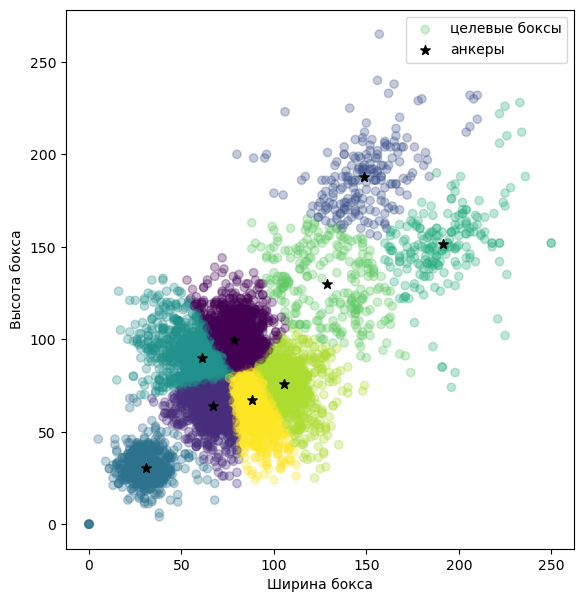

In [20]:
anchors = calculate_anchors(all_scaled_boxes_wh)

In [21]:
class AverageMeter:
    """Вычисляет и хранит среднее значения"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def prepare_targets(boxes, labels, device):
    """Подготавливаем targets для YOLO loss"""
    targets = []
    for batch_idx, (batch_boxes, batch_labels) in enumerate(zip(boxes, labels)):
        for box, label in zip(batch_boxes, batch_labels):
            if len(box) == 4:  # cx, cy, w, h
                cx, cy, w, h = box
                targets.append([batch_idx, label, cx, cy, w, h])
    return torch.tensor(targets, device=device) if targets else torch.tensor([], device=device)

def train(train_loader, model, criterion, optimizer, history, epoch, n_epochs, device, print_freq=10):
    """Тренировка одной эпохи"""
    model.train()
    batch_time = AverageMeter()
    data_time = AverageMeter()
    losses = AverageMeter()
    start = time.time()

    for i, (images, boxes, labels) in enumerate(train_loader):
        data_time.update(time.time() - start)
        images = images.to(device)

        # Подготавливаем targets
        targets = prepare_targets(boxes, labels, device)

        # Forward prop.
        predictions = model(images)

        # Loss
        loss = criterion(predictions, targets)

        # Backward prop.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.update(loss.item(), images.size(0))
        batch_time.update(time.time() - start)

        history['loss'].append(loss.item())

        start = time.time()

        if i % print_freq == 0:
            print(f'Epoch: {epoch}/{n_epochs}\t'
                  f'Batch {i}/{len(train_loader)}\t'
                  f'Loss {losses.val:.4f} ({losses.avg:.4f})\t')


def save_checkpoint(state_path, epoch, model, optimizer, history):
    """Сохраняем чекпоинт модели."""
    state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
    }
    torch.save(state, state_path)

def load_checkpoint(state_path, model, optimizer):
    """Загружаем чекпоинт модели."""
    if os.path.exists(state_path):
        checkpoint = torch.load(state_path, map_location='cpu')
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        history = checkpoint['history']
        start_epoch = checkpoint['epoch'] + 1
        print(f'Loaded checkpoint from epoch {start_epoch-1}')
        return start_epoch, history
    else:
        return 0, {'loss': []}

In [96]:
# Инициализация модели
model = YOLOv3(num_classes=3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
criterion = YoloLoss(anchors, num_classes=3)

# Загрузка чекпоинта если есть
start_epoch, history = load_checkpoint("checkpoint_yolov3.pth", model, optimizer)

model = model.to(device)
criterion = criterion.to(device)

# Обучение
for epoch in range(start_epoch, 50):
    train(train_loader=train_loader,
          model=model,
          criterion=criterion,
          optimizer=optimizer,
          history=history,
          epoch=epoch,
          n_epochs=50,
          device=device,
          print_freq=20)

    # Сохраняем чекпоинт
    save_checkpoint("checkpoint_yolov3.pth", epoch, model, optimizer, history)

In [22]:
model = YOLOv3(num_classes=3)
checkpoint = torch.load("model.pth")
print(checkpoint)
model.load_state_dict(checkpoint)
model = model.eval().to(device)

OrderedDict([('backbone.conv_in.conv.weight', tensor([[[[ 0.0236, -0.0863,  0.1260],
          [-0.0943, -0.1320,  0.0809],
          [ 0.1516,  0.0922,  0.1203]],

         [[ 0.0666,  0.0760, -0.0242],
          [-0.0295,  0.0757,  0.1013],
          [ 0.0077, -0.0525,  0.0385]],

         [[-0.0542,  0.1686, -0.1126],
          [-0.1089,  0.0892,  0.0833],
          [-0.1322, -0.1048, -0.1105]]],


        [[[ 0.0380, -0.0908, -0.1589],
          [-0.0356, -0.1346, -0.1905],
          [-0.0702,  0.1581,  0.1761]],

         [[-0.0289, -0.1484, -0.1240],
          [ 0.0958, -0.1566, -0.1309],
          [ 0.1808, -0.0990,  0.0901]],

         [[-0.0370, -0.1326, -0.1399],
          [ 0.1395, -0.1738, -0.1697],
          [ 0.1713, -0.1434, -0.1712]]],


        [[[-0.1790, -0.0486,  0.1070],
          [ 0.1450, -0.1592, -0.1919],
          [ 0.1768,  0.1005, -0.0509]],

         [[ 0.0204,  0.0881,  0.0117],
          [ 0.1433, -0.1088, -0.0935],
          [-0.0032, -0.0694,  0.0650]],

In [23]:
def decode_predictions(predictions, anchors, grid_sizes, num_classes, input_size, conf_threshold=0.5):
    all_boxes = []
    device = predictions[0].device
    anchors = [a.to(device) for a in anchors]

    for i, (p, S) in enumerate(zip(predictions, grid_sizes)):
        B, _, _, A, C = p.shape

        grid_y, grid_x = torch.meshgrid(torch.arange(S), torch.arange(S), indexing='ij')
        grid = torch.stack((grid_x, grid_y), dim=-1).float().to(device).view(1, S, S, 1, 2)

        stride = input_size / S
        scaled_anchors = (anchors[i] / stride).view(1, 1, 1, A, 2)

        pred_xy = torch.sigmoid(p[..., 0:2]) + grid
        box_xy = pred_xy * stride

        pred_wh = torch.exp(p[..., 2:4]) * scaled_anchors
        box_wh = pred_wh * stride

        objectness = torch.sigmoid(p[..., 4:5])
        class_probs = torch.sigmoid(p[..., 5:])

        p_flat = p.view(B, -1, C)
        box_xy_flat = box_xy.view(B, -1, 2)
        box_wh_flat = box_wh.view(B, -1, 2)
        objectness_flat = objectness.view(B, -1, 1)
        class_probs_flat = class_probs.view(B, -1, num_classes)

        box_x1y1 = box_xy_flat - box_wh_flat / 2
        box_x2y2 = box_xy_flat + box_wh_flat / 2
        boxes_xyxy = torch.cat([box_x1y1, box_x2y2], dim=-1)

        scores, class_indices = torch.max(class_probs_flat * objectness_flat, dim=-1)

        mask = scores > conf_threshold

        boxes_xyxy_filtered = boxes_xyxy[0, mask[0]]
        scores_filtered = scores[0, mask[0]]
        class_indices_filtered = class_indices[0, mask[0]]

        if boxes_xyxy_filtered.shape[0] > 0:
            all_boxes.append(torch.cat([
                boxes_xyxy_filtered,
                scores_filtered.unsqueeze(-1),
                class_indices_filtered.unsqueeze(-1).float()
            ], dim=-1))

    if not all_boxes:
        return torch.empty(0, 6, device=device)

    all_boxes_cat = torch.cat(all_boxes, dim=0)
    return all_boxes_cat

In [24]:
def nms(decoded_boxes, iou_threshold=0.45):
    """
    Выполняет Non-Maximum Suppression (NMS)
    """
    if decoded_boxes.shape[0] == 0:
        return torch.empty(0, 6)

    boxes_list = decoded_boxes.clone()
    final_boxes = []

    while boxes_list.shape[0] > 0:

        # 1. Сортируем оставшиеся боксы по score
        order = boxes_list[:, 4].argsort(descending=True)
        boxes_list = boxes_list[order]

        # 2. Берем лучший бокс
        best_box = boxes_list[0]
        final_boxes.append(best_box)

        if boxes_list.shape[0] == 1:
            break

        # 3. Берем все остальные боксы
        other_boxes = boxes_list[1:]

        # 4. Считаем IoU лучшего бокса со всеми остальными
        iou = bbox_iou(best_box[:4].unsqueeze(0), other_boxes[:, :4])

        # 5. Оставляем только те, у которых IoU <= порога
        non_overlapping_mask = iou <= iou_threshold

        # 6. Обновляем список на следующую итерацию
        boxes_list = other_boxes[non_overlapping_mask]

    if not final_boxes:
        return torch.empty(0, 6)

    return torch.stack(final_boxes)

In [25]:
def scale_boxes(boxes, img_shape_416, img_shape_orig):
    input_w, input_h = img_shape_416
    orig_w, orig_h = img_shape_orig

    scale_x = orig_w / input_w
    scale_y = orig_h / input_h

    boxes_scaled = boxes.clone()
    boxes_scaled[:, 0] *= scale_x # x1
    boxes_scaled[:, 1] *= scale_y # y1
    boxes_scaled[:, 2] *= scale_x # x2
    boxes_scaled[:, 3] *= scale_y # y2

    boxes_scaled[:, 0] = torch.clamp(boxes_scaled[:, 0], 0, orig_w)
    boxes_scaled[:, 1] = torch.clamp(boxes_scaled[:, 1], 0, orig_h)
    boxes_scaled[:, 2] = torch.clamp(boxes_scaled[:, 2], 0, orig_w)
    boxes_scaled[:, 3] = torch.clamp(boxes_scaled[:, 3], 0, orig_h)

    return boxes_scaled

In [30]:
img_dir = Path('test') / "images"
exts = {".jpg", ".jpeg", ".png"}
test_files = sorted([p.name for p in img_dir.rglob("*") 
                         if p.suffix.lower() in exts and ".ipynb_checkpoints" not in p.as_posix()])

In [31]:
def plot_boxes(
    boxes, labels, classes, ax, edgecolor='red', scores=None, threshold=None
    ):
    """
    Функция отрисовки bounding box-ов в задаче детекции.
    Аргументы:
      boxes -- массив боксов, которые задаются координатами
      xmin, ymin, xmax, ymax;
      labels -- лейблы классов;
      scores -- уверенность модели в детекции боксов;
      threshold -- порог отсечения боксов по threshold;
      ax -- полотно, на котором отображена исходная картинка.
    """

    box_kwargs = dict(linewidth=2, fill=False, edgecolor=edgecolor, facecolor='none')
    bbox = dict(facecolor='white', alpha=0.5)
    annot_kwargs = dict(color='black', size=14, bbox=bbox)

    for i, box in enumerate(boxes):

        if (scores is not None) and (threshold is not None) and (scores[i] < threshold):
            continue

        left_x, top_y, right_x, bottom_y = box
        width = right_x - left_x + 1
        height = bottom_y - top_y + 1

        # Прямоугольная рамка
        box_patch = Rectangle((left_x, top_y), width=width, height=height, **box_kwargs)
        # Добавляем рамку к изображению
        ax.add_patch(box_patch)

        # Добавляем текст к фото справа сверху от рамки
        if scores is not None:
            ax.text(left_x, top_y, f"{classes[labels[i]]}, {scores[i]:.2f}", **annot_kwargs)
        else:
            ax.text(left_x, top_y, f"{classes[labels[i]]}", **annot_kwargs)

In [32]:
vis_classes = CLASS_NAMES


Запуск инференса на 5 изображениях...


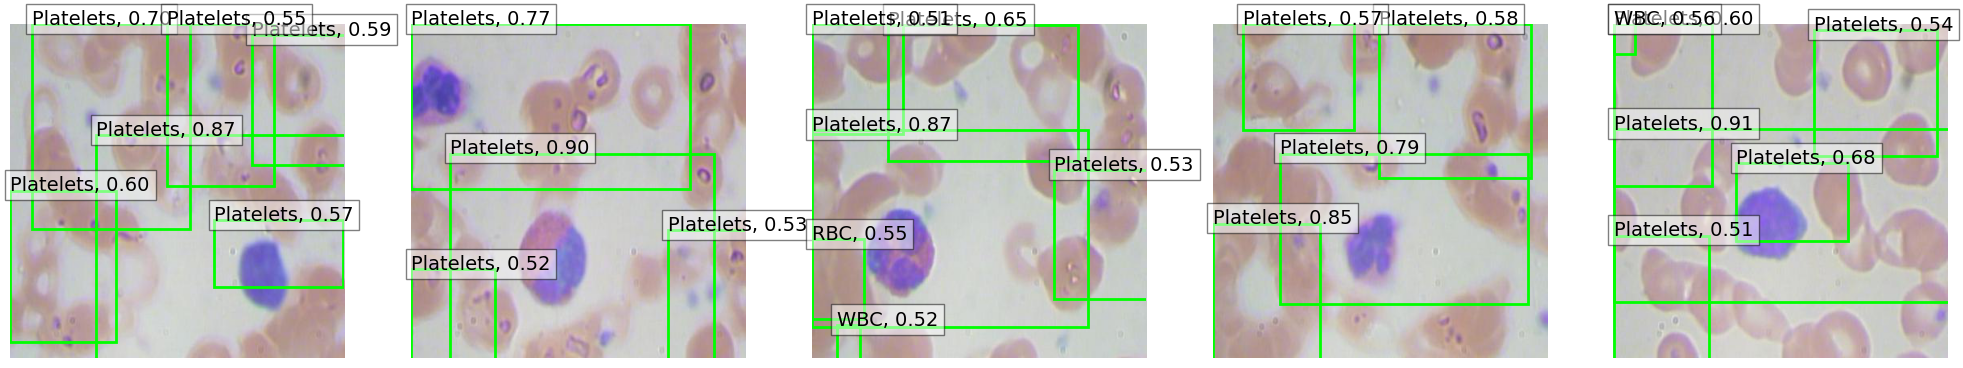

In [33]:
# 1 Якоря
ANCHORS = anchors

# 2. Размеры сеток (соответствуют анкерам)
GRID_SIZES = [13, 26, 52] # P5, P4, P3

# 3. Размер входа модели
INPUT_SIZE = 416

# 4. Классы

CLASSES = CLASS_NAMES
# А это кол-во классов, на которое обучалась МОДЕЛЬ.
NUM_CLASSES_MODEL = 3

# 5. Устройство
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 6. Путь к чекпоинту
CHECKPOINT_PATH = "model.pth"

# --- 1. Подготовка трансформаций ---
transform = transforms.Compose([
    transforms.Resize((416, 416)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Выбор тестовых изображений
test_files_to_plot = test_files[:5]

print(f"\nЗапуск инференса на {len(test_files_to_plot)} изображениях...")

fig, axes = plt.subplots(1, 5, figsize=(25, 16))
if len(test_files_to_plot) == 1:
    axes = [axes]

for i, file in enumerate(test_files_to_plot):
    img_path = os.path.join(img_dir, file)

    ax = axes[i]
    ax.axis("off")

    # Загрузка и подготовка изображения
    original_image = Image.open(img_path).convert('RGB')
    img_tensor = transform(original_image).unsqueeze(0).to(DEVICE)

    # Forward Pass (Получение "сырых" предсказаний)
    with torch.no_grad():
        predictions = model(img_tensor)

    # Декодирование
    decoded_boxes = decode_predictions(
        predictions, ANCHORS, GRID_SIZES,
        num_classes=NUM_CLASSES_MODEL,
        input_size=INPUT_SIZE,
        conf_threshold=0.5
    )

    # Non-Maximum Suppression

    final_boxes_nms = nms(decoded_boxes, iou_threshold=0.1)

    # --- 8. Масштабирование ---
    if final_boxes_nms.shape[0] > 0:
        boxes_scaled = scale_boxes(
            final_boxes_nms.cpu(),
            (INPUT_SIZE, INPUT_SIZE),
            original_image.size
        )
    else:
        boxes_scaled = torch.empty(0, 6)

    # Визуализация
    ax.imshow(original_image)

    if boxes_scaled.shape[0] > 0:
        plot_boxes(
            boxes=boxes_scaled[:, :4],
            labels=boxes_scaled[:, 5].int().tolist(),
            classes=vis_classes,
            ax=ax,
            edgecolor='lime',
            scores=boxes_scaled[:, 4].tolist(),
            threshold=0.0
        )
    else:
        ax.text(0.5, 0.5, "Объекты не найдены", transform=ax.transAxes,
                horizontalalignment='center', verticalalignment='center',
                fontsize=14, bbox=dict(boxstyle='round', facecolor='red', alpha=0.5))

In [39]:
def cxcywhn_to_xyxy(boxes_list_norm, img_size=416):
    """
    Конвертирует список тензоров [N, 4] из (cx, cy, w, h) нормализованных
    в (xmin, ymin, xmax, ymax) в абсолютных координатах.
    """
    boxes_list_abs = []
    for boxes_norm in boxes_list_norm:
        if boxes_norm.numel() == 0:
            boxes_list_abs.append(torch.empty(0, 4))
            continue

        cx, cy, w, h = boxes_norm.unbind(-1)

        # Денормализация
        cx_abs, w_abs = cx * img_size, w * img_size
        cy_abs, h_abs = cy * img_size, h * img_size

        # Конвертация в xyxy
        xmin = cx_abs - w_abs / 2
        ymin = cy_abs - h_abs / 2
        xmax = cx_abs + w_abs / 2
        ymax = cy_abs + h_abs / 2

        boxes_abs = torch.stack([xmin, ymin, xmax, ymax], dim=1)
        boxes_list_abs.append(boxes_abs)
    return boxes_list_abs



def evaluate_custom_model(checkpoint_path, test_dataset, anchors, grid_sizes, num_classes):

    # 1. Загрузка данных
    # Используем collate_fn
    test_loader = DataLoader(
        test_dataset,
        batch_size=8,
        shuffle=False,
        collate_fn=collate_fn
    )

    # 2. Загрузка модели
    model = YOLOv3(num_classes=num_classes).to(device)
    # Загружаем только state_dict, так как optimizer не нужен для инференса
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Модель загружена из {checkpoint_path}")
    else:
        print(f"Ошибка: Чекпоинт {checkpoint_path} не найден. Убедитесь, что модель обучена.")
        return

    model.eval()

    # 3. Инициализация метрики
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)

    print("Начало расчета метрик на тестовом наборе...")

    for images_batch, boxes_batch_norm, labels_batch in tqdm(test_loader):
        images_batch = images_batch.to(device)

        with torch.no_grad():
            # 4. Получение предсказаний модели
            predictions_raw = model(images_batch)

            batch_preds_formatted = []

            # Декодируем для каждого изображения в батче
            for i in range(images_batch.shape[0]):
                # Берем предсказания для i-го изображения
                preds_i = [p[i:i+1] for p in predictions_raw]

                # Декодируем (результат уже в xyxy 0-416)
                decoded_boxes = decode_predictions(
                    preds_i, anchors, grid_sizes,
                    num_classes=num_classes,
                    input_size=416,
                    conf_threshold=0.01 # Низкий порог для mAP
                )

                # NMS
                nms_boxes = nms(decoded_boxes, iou_threshold=0.45)

                # Форматируем для torchmetrics
                batch_preds_formatted.append({
                    'boxes': nms_boxes[:, :4].cpu(),
                    'scores': nms_boxes[:, 4].cpu(),
                    'labels': nms_boxes[:, 5].int().cpu()
                })

        # 5. Подготовка Ground Truth (Target)
        # Конвертируем GT боксы из (cx, cy, w, h, norm) -> (x, y, x, y, abs 416)
        target_boxes_abs = cxcywhn_to_xyxy(boxes_batch_norm, img_size=416)

        batch_target_formatted = []
        for i in range(len(target_boxes_abs)):
            batch_target_formatted.append({
                'boxes': target_boxes_abs[i].cpu(),
                'labels': labels_batch[i].int().cpu()
            })

        # 6. Обновление метрики
        metric.update(batch_preds_formatted, batch_target_formatted)

    # 7. Расчет и вывод
    print("\nРасчет метрик завершен.")
    results = metric.compute()
    return results

In [40]:
def evaluate_custom_model(checkpoint_path, test_dataset, anchors, grid_sizes, num_classes):

    # 1. Загрузка данных
    # Используем collate_fn
    test_loader = DataLoader(
        test_dataset,
        batch_size=8,
        shuffle=False,
        collate_fn=collate_fn
    )

    # 2. Загрузка модели
    model = YOLOv3(num_classes=num_classes).to(device)
    # Загружаем только state_dict, так как optimizer не нужен для инференса
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint)
        print(f"Модель загружена из {checkpoint_path}")
    else:
        print(f"Ошибка: Чекпоинт {checkpoint_path} не найден. Убедитесь, что модель обучена.")
        return

    model.eval()

    # 3. Инициализация метрики
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)

    print("Начало расчета метрик на тестовом наборе...")

    for images_batch, boxes_batch_norm, labels_batch in tqdm(test_loader):
        images_batch = images_batch.to(device)

        with torch.no_grad():
            # 4. Получение предсказаний модели
            predictions_raw = model(images_batch)

            batch_preds_formatted = []

            # Декодируем для каждого изображения в батче
            for i in range(images_batch.shape[0]):
                # Берем предсказания для i-го изображения
                preds_i = [p[i:i+1] for p in predictions_raw]

                # Декодируем (результат уже в xyxy 0-416)
                decoded_boxes = decode_predictions(
                    preds_i, anchors, grid_sizes,
                    num_classes=num_classes,
                    input_size=416,
                    conf_threshold=0.01 # Низкий порог для mAP
                )

                # NMS
                nms_boxes = nms(decoded_boxes, iou_threshold=0.45)

                # Форматируем для torchmetrics
                batch_preds_formatted.append({
                    'boxes': nms_boxes[:, :4].cpu(),
                    'scores': nms_boxes[:, 4].cpu(),
                    'labels': nms_boxes[:, 5].int().cpu()
                })

        # 5. Подготовка Ground Truth (Target)
        # Конвертируем GT боксы из (cx, cy, w, h, norm) -> (x, y, x, y, abs 416)
        target_boxes_abs = cxcywhn_to_xyxy(boxes_batch_norm, img_size=416)

        batch_target_formatted = []
        for i in range(len(target_boxes_abs)):
            batch_target_formatted.append({
                'boxes': target_boxes_abs[i].cpu(),
                'labels': labels_batch[i].int().cpu()
            })

        # 6. Обновление метрики
        metric.update(batch_preds_formatted, batch_target_formatted)

    # 7. Расчет и вывод
    print("\nРасчет метрик завершен.")
    results = metric.compute()
    return results

In [41]:
custom_metrics = evaluate_custom_model(
    "model.pth",
    test_dataset,
    ANCHORS,
    GRID_SIZES,
    NUM_CLASSES_MODEL
)

print("\n--- Метрики для  YOLOv3 ---")
print(f"mAP@.50:.95: {custom_metrics['map']:.4f}")
print(f"mAP@.50:     {custom_metrics['map_50']:.4f}")
print(f"mAP@.75:     {custom_metrics['map_75']:.4f}")

Модель загружена из model.pth
Начало расчета метрик на тестовом наборе...


  0%|          | 0/5 [00:00<?, ?it/s]

/home/kirill/miniconda3/envs/DScource/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)



Расчет метрик завершен.

--- Метрики для  YOLOv3 ---
mAP@.50:.95: 0.1863
mAP@.50:     0.5245
mAP@.75:     0.1006


**Выводы:**

Модель предоставляет достаточно гибкий функционал для подбора параметров, неплохо справляется с детекцией

---
### Задача 2

**Новый backbone: CSP-Darknet для YOLOv3**

На этом шаге мы переходим от оригинального Darknet-53, используемого в YOLOv3, к более современной архитектуре backbone **CSP-Darknet из YOLOv8**. На изображении **ниже показана схема YOLOv8** и детально разобраны компоненты архитектуры. Мы будем использовать **конфигурацию S**, которой соответствуют множители  $ d = 0.33 $, $ w = 0.5 $, $ r = 2 $,  которые задают эффективную глубину, ширину и отношение каналов в backbone (см. таблицу на схеме).

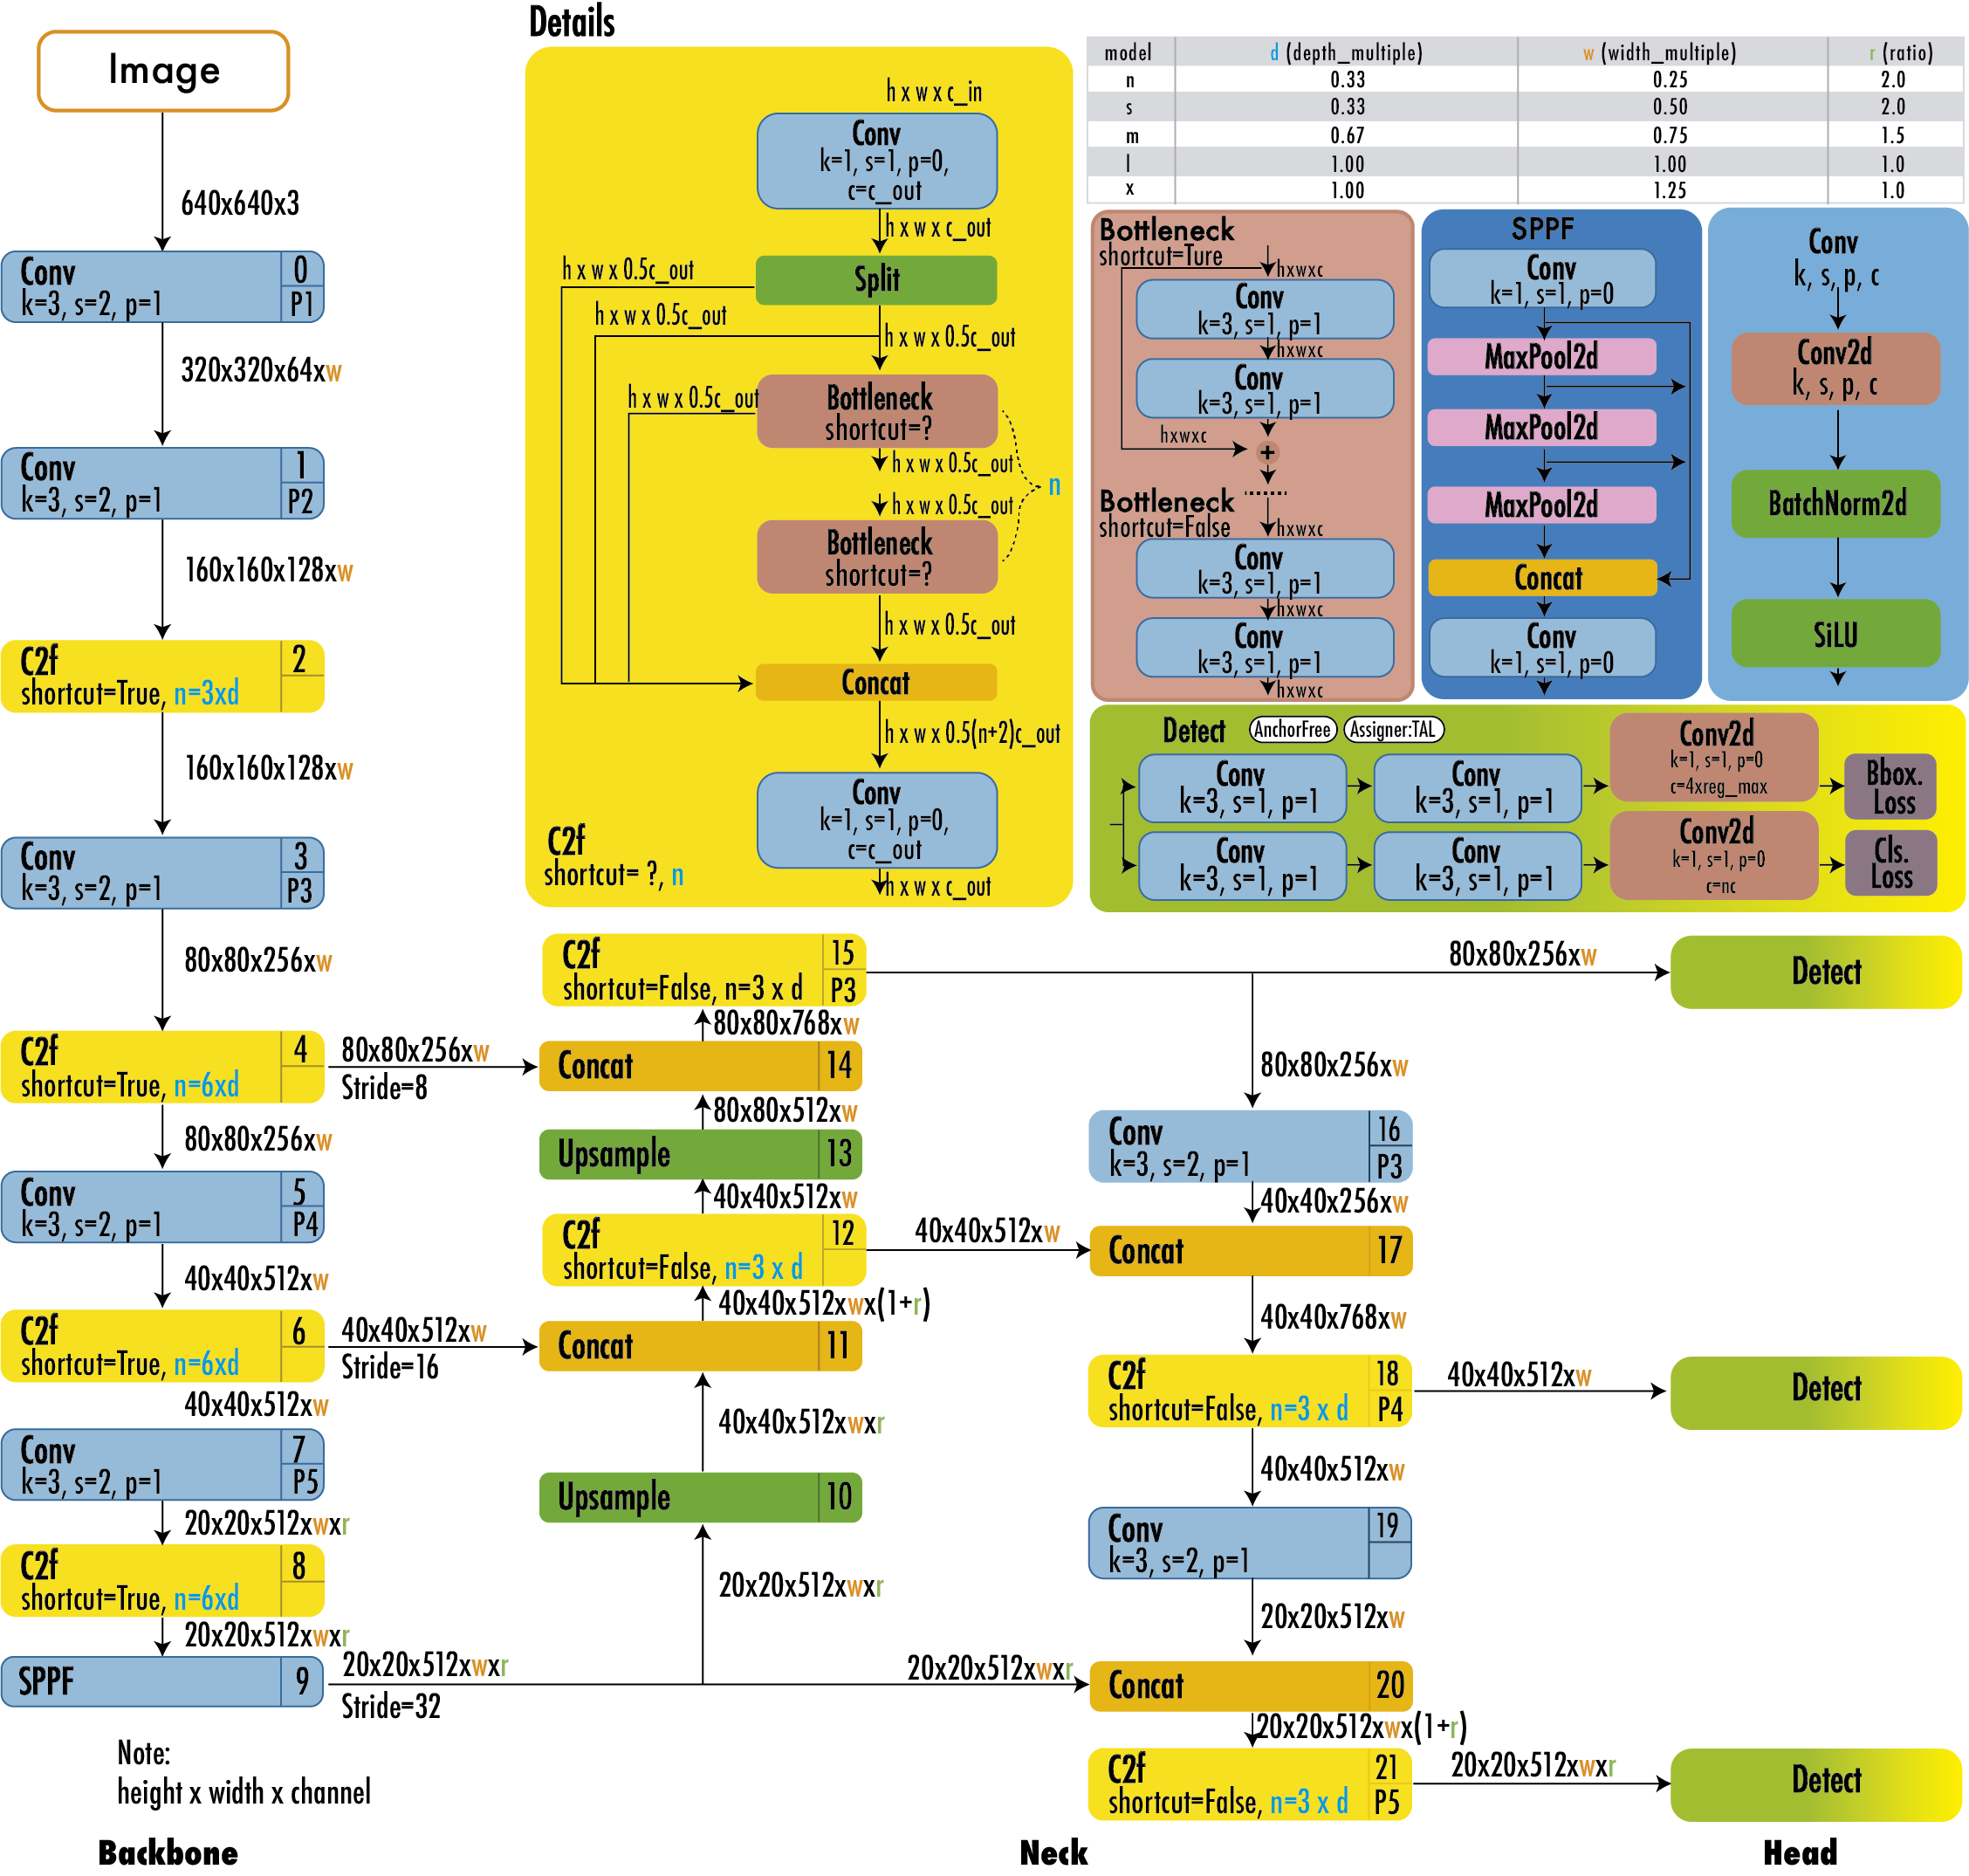

**Разберем подробнее, что из себя представляет новый backbone, следуя схеме выше.**

Новый backbone **CSP-Darknet из YOLOv8** включает в себя:
* сверточные слои вида `Conv` $\rightarrow$ `BatchNorm` $\rightarrow$ `SiLU`,
* повторяющиеся **C2f-блоки**,
* **SPPF** блок на конце backbone.

Backbone принимает на вход тензор изображения и возвращает пирамиду признаков для уровней детекции $P_3, P_4, P_5$.

Опишем **C2f-блоки**. Каждый такой элемент
1. получает входной тензор размера $b \times c_{in} \times h \times w$;
2. преобразует число каналов до $c_{out}$ с помощью свертки $1 \times 1$;
3. разделяет карту признаков по размерности каналов на две ветви (операция `Split`);
4. последовательно пропускает одну из ветвей через цепочку из $n$ bottleneck-блоков, сохраняя вход и выход как отдельные ветви;
5. конкатенирует выходы всех ветвей по размерности каналов;
6. приводит результат к $c_{out}$ каналам с помощью свертки $1 \times 1$.

Таким образом, C2f сочетает **короткие остаточные связи** внутри bottleneck-блоков и **длинные skip-соединения** между ветвями. Это улучшает распространение градиента и перераспределение информации по каналам по сравнению с Darknet-53.

**SPFF** (Spatial Pyramid Pooling - Fast) блок работает по следующему принципу:
1. берет карту признакови с помощью свертки $1 \times 1$ уменьшает количество каналов вдвое;
2. пропускает её через один слой Max Pooling с ядром 5x5 и шагом 1;
3. результат предыдущего шага снова пропускает через Max Pooling 5x5 и шагом 1 (это эквивалентно одному пулингу 9x9 на исходной карте;
4. результат шага 3 еще раз пропускает через Max Pooling 5x5 и шагом 1 (это эквивалентно пулингу 13x13 на исходной карте);
5. соединяет исходную карту признаков и результаты трех последовательных пулингов и с помощью свертки меняет количетсво каналов.

По итогу SPPF обогащает данные мультимасштабным контекстом, помогая модели лучше понять окружение и размер объекта.

Реализуйте новый **Conv**-блок.

In [ ]:
# При реализации класса запрещено пользоваться ИИ-инструментами.


class Conv(nn.Module):
    def __init__(
        self,
        c_in,
        c_out,
        kernel_size,
        stride=1,
        padding=None,
    ) -> None:
        """
        Инициализация Conv-блока.

        Args:
            c_in: Число входных каналов.
            c_out: Число выходных каналов.
            kernel_size: Размер ядра свертки.
            stride: Шаг свертки.
            padding: Отступ свертки.
        """
        super().__init__()
        ...

    def forward(self, x):
        """Прямой проход через conv-блок."""
        ...

Реализуйте **Bottleneck**, используемый в **C2f-блоках**.

In [ ]:
# При реализации класса запрещено пользоваться ИИ-инструментами.


class Bottleneck(nn.Module):
    """Остаточный bottleneck-блок, используемый внутри C2f."""

    def __init__(
        self,
        c_in: int,
        c_out: int,
        shortcut: bool = True,
        expansion: float = 0.5,
    ) -> None:
        """
        Инициализация bottleneck-блока.

        Args:
            c_in: Число входных каналов.
            c_out: Число выходных каналов.
            shortcut: Использовать ли остаточное соединение.
            expansion: Коэффициент расширения скрытых каналов.
        """
        super().__init__()
        ...

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Прямой проход через bottleneck-блок.

        Args:
            x: Входной тензор формы [B, C, H, W].

        Returns:
            Выходной тензор формы [B, C, H, W].
        """
        ...

Реализуйте **C2f-блок**.

In [ ]:
# При реализации класса запрещено пользоваться ИИ-инструментами.


class C2f(nn.Module):
    """C2f-блок по мотивам backbone YOLOv8."""

    def __init__(
        self,
        c_in: int,
        c_out: int,
        n: int = 1,
        shortcut: bool = True,
        expansion: float = 0.5,
    ) -> None:
        """
        Инициализация C2f-блока.

        Args:
            c_in: Число входных каналов.
            c_out: Число выходных каналов.
            n: Число внутренних bottleneck-блоков.
            shortcut: Включать ли остаточные связи в bottleneck-блоках.
            expansion: Коэффициент расширения скрытых каналов.
        """
        super().__init__()
        ...

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Прямой проход через C2f-блок.

        Args:
            x: Входной тензор формы [B, C_in, H, W].

        Returns:
            Выходной тензор формы [B, C_out, H, W].
        """
        ...

Реализуйте **SPPF-блок**.

In [ ]:
# При реализации класса запрещено пользоваться ИИ-инструментами.


class SPPF(nn.Module):
    """SPPF-блок по мотивам backbone YOLOv8."""

    def __init__(
        self,
        c_in: int,
        c_out: int,
    ) -> None:
        """
        Инициализация SPPF-блока.

        Args:
            c_in: Число входных каналов.
            c_out: Число выходных каналов.
        """
        super().__init__()
        ...

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Прямой проход через SPPF-блок.

        Args:
            x: Входной тензор формы [B, C_in, H, W].

        Returns:
            Выходной тензор формы [B, C_out, H, W].
        """

Соберите из составляющих блоков **YOLOv8 CSP-Darknet backbone конфигурации S**.

In [ ]:
# При реализации класса запрещено пользоваться ИИ-инструментами.


class YOLOv8Backbone(nn.Module):
    """Backbone в стиле YOLOv8 на основе сверточных и C2f-блоков."""

    def __init__(self) -> None:
        """Инициализация backbone конфигурации S."""
        super().__init__()
        ...

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Прямой проход backbone и получение многоуровневых карт признаков.

        Args:
            x: Пакет изображений формы [B, 3, H, W].

        Returns:
            Кортеж карт признаков для уровней детекции, например (P3, P4, P5).
        """
        ...

Получите **модификацию YOLOv3**, добавив к ней новый backbone.

In [ ]:
# При реализации класса запрещено пользоваться ИИ-инструментами.


class YOLOv3_CSPDarknet(nn.Module):
    """Модификация YOLOv3 с CSP-Darknet в стиле YOLOv8."""

    def __init__(self, num_classes: int = NUM_CLASSES) -> None:
        """
        Инициализация модели YOLOv3 с новым backbone.

        Args:
            num_classes: Число классов объектов.
        """
        super().__init__()
        self.backbone: YOLOv8Backbone = ...
        self.neck: nn.Module = ...
        self.head: nn.Module = ...
        self.num_classes: int = num_classes
        self.num_anchors: int = ...

    def _format_output(self, tensor: torch.Tensor) -> torch.Tensor:
        """
        Переформатирование выхода головы детекции.

        Args:
            tensor: Тензор предсказаний формы [B, C, H, W].

        Returns:
            Тензор формы [B, H, W, num_anchors, C_per_anchor].
        """
        b, c, h, w = tensor.shape
        tensor = tensor.view(b, self.num_anchors, -1, h, w)
        tensor = tensor.permute(0, 3, 4, 1, 2).contiguous()
        return tensor

    def forward(self, x: torch.Tensor) -> list[torch.Tensor]:
        """
        Прямой проход модели YOLOv3 с C2f-бэкбоном.

        Args:
            x: Пакет изображений формы [B, 3, H, W].

        Returns:
            Список тензоров предсказаний для разных уровней признаков.
        """
        ...

Обучите и протестируйте новую модель по такому же алгоритму, что и YOLOv3.

In [ ]:
...

Получилось ли улушить качество детекции? В чем преимущества нового backbone?

**Выводы:**

...

---
### Задача 3.
**Новый neck: FPN → PAN-FPN**

В исходной YOLOv3 в качестве neck используется FPN (Feature Pyramid Network). Поток признаков идёт **сверху вниз**: от глубоких слоёв с низким разрешением ($P_5$) к более мелким ($P_4$, $P_3$). Это улучшает локализацию мелких объектов, но часть информации о глобальном контексте теряется, так как движение одностороннее.

В YOLOv8 используется расширенная схема **PAN-FPN (Path Aggregation Network)**. К исходному top-down пути добавляется **bottom-up путь**: признаки дополнительно поднимаются снизу вверх, что позволяет повторно использовать низкоуровневые детали и лучше объединять локальные и глобальные признаки (см. схему архитектуры YOLOv8).

В результате neck:

- принимает пирамиду признаков $(P_3, P_4, P_5)$ из backbone;
- выполняет путь снизу вверх (bottom-up), а затем сверху вниз (top-down);
- возвращает обновлённые уровни признаков $(P_3^{\text{out}}, P_4^{\text{out}}, P_5^{\text{out}})$ для головы детекции.


**Структура PAN-FPN**

1. **Bottom-up путь (движение вверх по пирамиде):**
   - $P_5 \;\rightarrow$ upsample в $2$ раза $\;\rightarrow$ конкатенация с $P_4 \;\rightarrow$ C2f-блок;
   - результат $\;\rightarrow$ upsample в $2$ раза $\;\rightarrow$ конкатенация с $P_3 \;\rightarrow$ C2f-блок.

2. **Top-down путь (обратно вниз по пирамиде):**
   - обновлённый $P_3 \;\rightarrow$ downsample со stride $2 \;\rightarrow$ конкатенация с обновлённым $P_4 \;\rightarrow$ C2f-блок;
   - результат $\;\rightarrow$ downsample со stride $2 \;\rightarrow$ конкатенация с обновлённым $P_5 \;\rightarrow$ C2f-блок.

3. **Результат работы neck:**
   - три уровня признаков: $P_3^{\text{out}}$, $P_4^{\text{out}}$, $P_5^{\text{out}}$, которые подаются в голову детекции.


Реализуйте **PAN-FPN**.

In [ ]:
# При реализации класса запрещено пользоваться ИИ-инструментами.


class YOLONeck_PAN(nn.Module):
    """Neck в стиле YOLOv8: PAN-FPN с bottom-up и top-down путями."""

    def __init__(self) -> None:
        """Инициализация PAN-нейка на C2f-блоках."""
        super().__init__()
        ...

    def forward(
        self,
        p3: torch.Tensor,
        p4: torch.Tensor,
        p5: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Прямой проход через PAN-нейк.

        Args:
            p3: Карта признаков низкого уровня (наиболее высокое разрешение).
            p4: Среднеуровневая карта признаков.
            p5: Карта признаков высокого уровня (наименьшее разрешение).

        Returns:
            Кортеж из трёх обновлённых карт признаков:
            (P3_out, P4_out, P5_out).
        """
        ...

Добавьте FPN-PAN в архитектуру модели из предыдущей задачи.

In [ ]:
# При реализации класса запрещено пользоваться ИИ-инструментами.


class YOLOv3_CSPDarknet_PAN(nn.Module):
    """Модификация YOLOv3 с CSPDarknet-бэкбоном и PAN-неком."""

    def __init__(self, num_classes: int = NUM_CLASSES) -> None:
        """
        Инициализация модели YOLOv3 с CSPDarknet-бэкбоном и PAN-неком.

        Args:
            num_classes: Число классов объектов.
        """
        super().__init__()
        self.backbone: nn.Module = ...
        self.neck: YOLONeck_PAN = ...
        self.head: nn.Module = ...
        self.num_classes: int = num_classes
        self.num_anchors: int = ...

    def _format_output(self, tensor: torch.Tensor) -> torch.Tensor:
        """
        Переформатирование выхода головы детекции.

        Args:
            tensor: Тензор предсказаний формы [B, C, H, W].

        Returns:
            Тензор формы [B, H, W, num_anchors, C_per_anchor].
        """
        b, c, h, w = tensor.shape
        tensor = tensor.view(b, self.num_anchors, -1, h, w)
        tensor = tensor.permute(0, 3, 4, 1, 2).contiguous()
        return tensor

    def forward(self, x: torch.Tensor) -> List[torch.Tensor]:
        """
        Прямой проход модели YOLOv3 с CSPDarknet-бэкбоном и PAN-неком.

        Args:
            x: Пакет изображений формы [B, 3, H, W].

        Returns:
            Список тензоров предсказаний для разных уровней признаков.
        """
        ...

Обучите и протестируйте новую модель по такому же алгоритму, что и YOLOv3.

In [ ]:
...

Получилось ли улушить качество детекции? В чем преимущества нового neck?

**Выводы:**

...

---
### Задача 4

**Новый лосс: CIoU + Focal**

На последнем шаге мы доводим функцию потерь до формата, близкого к YOLOv8.

**CIoU Loss**

Для регрессии боксов в YOLOv8 используется CIoU Loss, который учитывает не только перекрытие, но и геометрию прямоугольников:

$$
L_{\text{CIoU}} = 1 - \text{IoU} + \frac{\rho^2(\mathbf{b}, \mathbf{b}^{\text{gt}})}{c^2} + \alpha v,
$$

где:
- $\text{IoU}$ — Intersection over Union предсказанного и истинного боксов;
- $\rho^2(\mathbf{b}, \mathbf{b}^{\text{gt}})$ — квадрат расстояния между центрами предсказанного и истинного боксов;
- $c^2$ — квадрат диагонали наименьшего охватывающего прямоугольника;
- $v$ — разница в соотношении сторон:

$$
v = \frac{4}{\pi^2} \left( \arctan\left(\frac{w^{\text{gt}}}{h^{\text{gt}}}\right) - \arctan\left(\frac{w}{h}\right) \right)^2,
$$

- $\alpha$ — адаптивный вес:

$$
\alpha = \frac{v}{(1 - \text{IoU}) + v}.
$$

**Focal Loss**

Для objectness и классов используется Focal BCE-лосс, который мы изучали ранее. Он уменьшает вклад «лёгких» примеров и усиливает влияние сложных.

Реализуйте новые лоссы.

In [ ]:
# При реализации класса запрещено пользоваться ИИ-инструментами.


class BoxCIoULoss(nn.Module):
    """Вычисляет Complete Intersection over Union (CIoU) Loss для координат боксов.

    Потери рассчитываются только для позиций, где присутствует объект (`obj_mask`).
    """

    def __init__(self):
        """Инициализирует слой потерь."""
        super().__init__()
        ...

    def forward(
        self, pred_box: torch.Tensor, target_box: torch.Tensor, obj_mask: torch.Tensor
    ) -> torch.Tensor:
        """
        Args:
            pred_box (torch.Tensor): Предсказанные боксы (N, ..., 4) в формате [cx, cy, w, h].
            target_box (torch.Tensor): Истинные боксы (N, ..., 4) в формате [cx, cy, w, h].
            obj_mask (torch.Tensor): Маска (N, ...), отмечающая позиции с объектами.

        Returns:
            torch.Tensor: Скалярное значение потерь.
        """
        ...


class ObjectnessFocalLoss(nn.Module):
    """Вычисляет Focal Loss для предсказания наличия объекта (`objectness`).

    Раздельно обрабатывает позиции с объектами (`obj_mask`) и без них (`noobj_mask`),
    чтобы бороться с дисбалансом классов.
    """

    def __init__(self):
        """Инициализирует слой потерь."""
        super().__init__()
        ...

    def forward(
        self,
        pred_obj: torch.Tensor,
        target_obj: torch.Tensor,
        obj_mask: torch.Tensor,
        noobj_mask: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            pred_obj (torch.Tensor): Предсказанные логиты `objectness` (N, ..., 1).
            target_obj (torch.Tensor): Истинные метки `objectness` (0 или 1) (N, ..., 1).
            obj_mask (torch.Tensor): Маска позиций с объектами.
            noobj_mask (torch.Tensor): Маска позиций без объектов (фон).

        Returns:
            torch.Tensor: Скалярное значение потерь.
        """
        ...


class ClassFocalLoss(nn.Module):
    """Вычисляет Focal Loss для задачи классификации объектов.

    Потери рассчитываются только для позиций, где присутствует объект (`obj_mask`).
    """

    def __init__(self):
        """Инициализирует слой потерь."""
        super().__init__()
        ...

    def forward(
        self, pred_class: torch.Tensor, target_class: torch.Tensor, obj_mask: torch.Tensor
    ) -> torch.Tensor:
        """
        Args:
            pred_class (torch.Tensor): Предсказанные логиты классов (N, ..., C).
            target_class (torch.Tensor): Истинные метки классов (N, ..., C), обычно one-hot.
            obj_mask (torch.Tensor): Маска (N, ...), отмечающая позиции с объектами.

        Returns:
            torch.Tensor: Скалярное значение потерь.
        """
        ...

Обучите и протестируйте модель из предыдущей задачи с новым лоссом по такому же алгоритму, что и YOLOv3.

Как влияет новый лосс на качество и характер ошибок модели по сравнению с прошлым экспериментом?

Стало ли меньше пропусков / лишних детекций?

**Выводы:**

...

**Итоговые выводы**

Напишите выводы по задаче. Также ответьте на вопросы:

- Если сравнить самую первую модель и последнюю, в чём, на ваш взгляд, состоит главный «скачок» в качестве?

- Какие изменения (backbone, neck, head, loss) оказались наиболее важными именно для этого датасета?  

...


---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока